In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import warnings
import sys
import seaborn as sns
import matplotlib.pyplot as plt

warnings.simplefilter(action="ignore", category=FutureWarning)

# Voeg de src-folder toe aan je Python path
src_path = Path("../src").resolve()
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from dataloader import load_data
from config import Config


In [2]:
config_path = Path("../config.toml").resolve()
config = Config.load(config_path)
df = load_data(config)

df

/home/azureuser/MADS-DAV-MEL/data/processed


,timestamp,message,author,age,gender
0,2013-08-17 10:14:17,‎Loïs Vriens heeft deze groep gemaakt\n,good-natured-ermine,25.0,f
1,2023-08-16 19:50:13,‎Bram Van Den Oever heeft je toegevoegd\n,furry-binturong,NaN,None
2,2023-08-16 19:59:39,‎Dit bericht is verwijderd.\n,good-natured-ermine,25.0,f
3,2023-08-16 20:00:35,‎ ‎GIF weggelaten\n,good-natured-ermine,25.0,f
4,2023-08-16 20:07:02,Klasse goed bezig 😁\n,snappy-ermine,30.0,m
...,...,...,...,...,...
9893,2025-03-16 17:16:14,"Thanks 😊\nFf tussenstop op Tenerife, crew wis...",crystalline-turkey,37.0,m
9894,2025-03-16 22:33:05,"Wij zijn weer in Nederland, net de wieltjes w...",crystalline-turkey,37.0,m
9895,2025-03-17 07:24:32,Welcome back! 💪🏻\n,groovy-salmon,35.0,m
9896,2025-03-17 15:14:03,‎ ‎afbeelding weggelaten\n,good-natured-ermine,25.0,f


In [ ]:
# Ik laat zien hoe de berichtenactiviteit zich opbouwt in de 14 dagen vóór carnaval, per jaar.

# DataFrame met startdata van carnaval per jaar
carnaval_data = pd.DataFrame({
    "year": [2024, 2025],
    "start_date": [pd.Timestamp("2024-02-08"), pd.Timestamp("2025-02-27")]
})

# Voeg kolom 'carnaval_year' toe aan de dataframe (alleen 2024 en 2025 genomen, 2023 zat rond carnaval nog niet in de chat)

def get_carnaval_year(ts):
    for _, row in carnaval_data.iterrows():
        start = row["start_date"]
        if ts >= (start - pd.Timedelta(days=14)) and ts <= (start + pd.Timedelta(days=5)):
            return row["year"]
    return None

df["carnaval_year"] = df["timestamp"].apply(get_carnaval_year)

df

,timestamp,message,author,age,gender,carnaval_year
0,2013-08-17 10:14:17,‎Loïs Vriens heeft deze groep gemaakt\n,good-natured-ermine,25.0,f,NaN
1,2023-08-16 19:50:13,‎Bram Van Den Oever heeft je toegevoegd\n,furry-binturong,NaN,None,NaN
2,2023-08-16 19:59:39,‎Dit bericht is verwijderd.\n,good-natured-ermine,25.0,f,NaN
3,2023-08-16 20:00:35,‎ ‎GIF weggelaten\n,good-natured-ermine,25.0,f,NaN
4,2023-08-16 20:07:02,Klasse goed bezig 😁\n,snappy-ermine,30.0,m,NaN
...,...,...,...,...,...,...
9893,2025-03-16 17:16:14,"Thanks 😊\nFf tussenstop op Tenerife, crew wis...",crystalline-turkey,37.0,m,NaN
9894,2025-03-16 22:33:05,"Wij zijn weer in Nederland, net de wieltjes w...",crystalline-turkey,37.0,m,NaN
9895,2025-03-17 07:24:32,Welcome back! 💪🏻\n,groovy-salmon,35.0,m,NaN
9896,2025-03-17 15:14:03,‎ ‎afbeelding weggelaten\n,good-natured-ermine,25.0,f,NaN


In [6]:
# filter op berichten in aanloop naar carnaval
df_carnaval = df[df["carnaval_year"].notna()].copy()

df_carnaval


,timestamp,message,author,age,gender,carnaval_year
2932,2024-01-25 08:34:29,‎ ‎afbeelding weggelaten\n,decorated-shark,55.0,f,2024.0
2933,2024-01-25 08:38:06,‎ ‎afbeelding weggelaten\n,amusing-owl,36.0,m,2024.0
2934,2024-01-25 08:43:54,Nice😄\n,decorated-shark,55.0,f,2024.0
2935,2024-01-25 08:45:36,Droogt dat als het zo koud is?\n,merry-sparrow,28.0,f,2024.0
2936,2024-01-25 08:46:34,‎ ‎afbeelding weggelaten\n,merry-sparrow,28.0,f,2024.0
...,...,...,...,...,...,...
9735,2025-03-03 17:59:47,‎ ‎afbeelding weggelaten\n,good-natured-ermine,25.0,f,2025.0
9736,2025-03-03 18:03:47,En leuke foto van blue\n,amusing-owl,36.0,m,2025.0
9737,2025-03-03 18:06:04,Nice😁\n,decorated-shark,55.0,f,2025.0
9738,2025-03-03 18:06:36,Carnavalsstrikje?\n,decorated-shark,55.0,f,2025.0


In [ ]:
# Voeg startdatum toe per jaar
df_carnaval = df_carnaval.merge(carnaval_data, left_on="carnaval_year", right_on="year", how="left")

# voeg dagen tot carnaval toe
df_carnaval["days_until_carnaval"] = (df_carnaval["timestamp"].dt.floor("D") - df_carnaval["start_date"]).dt.days

df_carnaval

,timestamp,message,author,age,gender,carnaval_year,year,start_date,days_until_carnaval
0,2024-01-25 08:34:29,‎ ‎afbeelding weggelaten\n,decorated-shark,55.0,f,2024.0,2024,2024-02-08,-14
1,2024-01-25 08:38:06,‎ ‎afbeelding weggelaten\n,amusing-owl,36.0,m,2024.0,2024,2024-02-08,-14
2,2024-01-25 08:43:54,Nice😄\n,decorated-shark,55.0,f,2024.0,2024,2024-02-08,-14
3,2024-01-25 08:45:36,Droogt dat als het zo koud is?\n,merry-sparrow,28.0,f,2024.0,2024,2024-02-08,-14
4,2024-01-25 08:46:34,‎ ‎afbeelding weggelaten\n,merry-sparrow,28.0,f,2024.0,2024,2024-02-08,-14
...,...,...,...,...,...,...,...,...,...
738,2025-03-03 17:59:47,‎ ‎afbeelding weggelaten\n,good-natured-ermine,25.0,f,2025.0,2025,2025-02-27,4
739,2025-03-03 18:03:47,En leuke foto van blue\n,amusing-owl,36.0,m,2025.0,2025,2025-02-27,4
740,2025-03-03 18:06:04,Nice😁\n,decorated-shark,55.0,f,2025.0,2025,2025-02-27,4
741,2025-03-03 18:06:36,Carnavalsstrikje?\n,decorated-shark,55.0,f,2025.0,2025,2025-02-27,4


In [ ]:
# Tel berichten per dag in aanloop naar carnaval
agg = df_carnaval.groupby(["carnaval_year", "days_until_carnaval"]).size().reset_index(name="message_count")

agg

,carnaval_year,days_until_carnaval,message_count
0,2024.0,-14,22
1,2024.0,-13,25
2,2024.0,-12,11
3,2024.0,-9,2
4,2024.0,-8,13
5,2024.0,-7,25
6,2024.0,-6,24
7,2024.0,-5,78
8,2024.0,-4,27
9,2024.0,-2,4


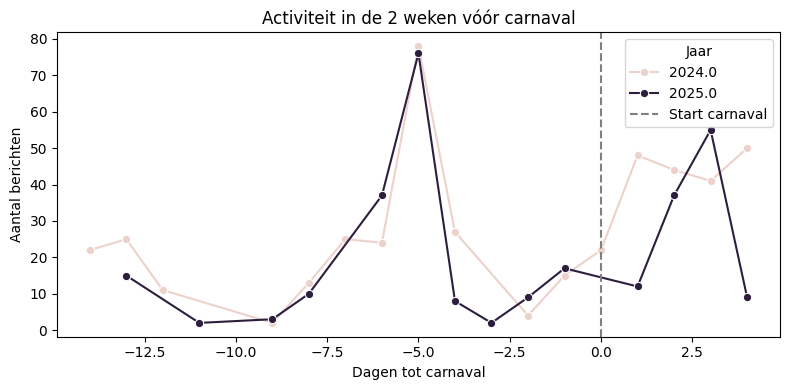

In [ ]:
# plot de grafiek

plt.figure(figsize=(8,4))
sns.lineplot(data=agg, x="days_until_carnaval", y="message_count", hue="carnaval_year", marker="o")
plt.axvline(0, color="gray", linestyle="--", label="Start carnaval")
plt.title("Activiteit in de 2 weken vóór carnaval")
plt.xlabel("Dagen tot carnaval")
plt.ylabel("Aantal berichten")
plt.legend(title="Jaar")
plt.tight_layout()
plt.show()


​Vijf dagen voor de start van carnaval in Son en Breugel, staan de volgende activiteiten gepland:​
- Zittingsavond (Tent): Een avond vol optredens en feestelijkheden georganiseerd door CV de Krutjesrapers. ​
- Disco Avond: Een discoavond voor de jeugd in Jongerencentrum Oase. ​
Deze evenementen markeren het begin van de carnavalsweek in Son en Breugel, waarbij de gemeenschap samenkomt om de festiviteiten in te luiden.

De piek in het aantal berichten zo’n vijf dagen voor carnaval is dus eigenlijk heel logisch: dan is de zittingsavond in het dorp. Een vaste traditie waar de familie elk jaar bij is. Er wordt dan volop overlegd, voorpret gedeeld en afspraken gemaakt in de chat. Dat zie je meteen aan de activiteit.


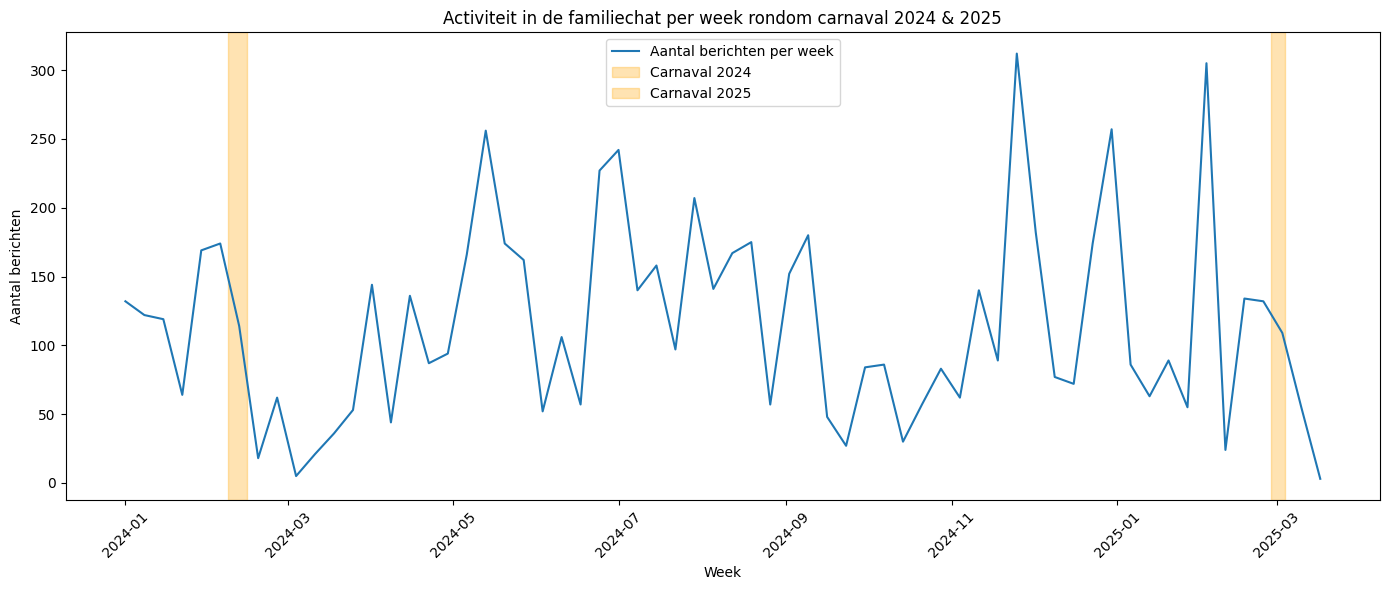

In [14]:
# Zorg dat 'timestamp' en 'date' goed staan
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['week'] = df['timestamp'].dt.to_period('W').apply(lambda r: r.start_time.date())

# Filter op berichten vanaf 1 september 2023
start_date = pd.to_datetime('2024-01-01').date()
df_filtered = df[df['week'] >= start_date]

# Tel aantal berichten per week
weekly_counts = df_filtered.groupby('week').size().reset_index(name='message_count')

# Zet carnavalperiodes in een lijst [(start, end, label)]
carnavals = [
    (pd.to_datetime('2024-02-08').date(), pd.to_datetime('2024-02-15').date(), 'Carnaval 2024'),
    (pd.to_datetime('2025-02-27').date(), pd.to_datetime('2025-03-04').date(), 'Carnaval 2025')
]

# Plot
plt.figure(figsize=(14, 6))
plt.plot(weekly_counts['week'], weekly_counts['message_count'], label='Aantal berichten per week', color='tab:blue')

# Carnaval highlighten
for start, end, label in carnavals:
    plt.axvspan(start, end, color='orange', alpha=0.3, label=label)

# Zorg dat labels niet dubbel zijn in de legenda
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.xlabel('Week')
plt.ylabel('Aantal berichten')
plt.title('Activiteit in de familiechat per week rondom carnaval 2024 & 2025')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In deze grafiek zie je het aantal berichten per week in de familiechat, vanaf januari 2024. De lichtoranje vlakken markeren de carnavalsweken van 2024 en 2025.

Opvallend is dat in beide jaren de activiteit flink toeneemt in de weken vóór carnaval. Vooral zo’n één tot twee weken voor carnaval is er een duidelijke piek te zien — een teken dat de familie dan volop bezig is met de voorbereidingen. Denk aan het afstemmen van plannen, outfits, wie waar slaapt, en natuurlijk: heel veel voorpret. 

De zittingsavond — vijf dagen voor carnaval — speelt hier waarschijnlijk ook een rol in, net als de eerste aankondigingen van activiteiten en themadagen.